# Titanic Dataset - Random Forest Hyperparameter Tuning
This notebook demonstrates cleaning the **Titanic dataset**, handling missing features, creating encoding pipelines, tuning a **Random Forest Classifier** using both `GridSearchCV` and `RandomizedSearchCV`, and evaluating their results.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, validation_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [2]:
# 1. Load and Preprocess Data
titanic_df = pd.read_csv('titanic.csv')
print("First 5 rows of data:")
print(titanic_df.head())

First 5 rows of data:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.05

In [3]:
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X = titanic_df[features]
y = titanic_df['Survived']

numeric_features = ['Age', 'Fare', 'SibSp', 'Parch']
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [4]:
categorical_features = ['Pclass', 'Sex', 'Embarked']
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print(f"\nTitanic Train Shape: {X_train_proc.shape}")
print(f"Titanic Test Shape: {X_test_proc.shape}")


Titanic Train Shape: (712, 12)
Titanic Test Shape: (179, 12)


In [6]:
# 2. GridSearchCV tuning
print("\nRunning GridSearchCV...")
rf = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_proc, y_train)

best_rf_grid = grid_search.best_estimator_
y_pred_grid = best_rf_grid.predict(X_test_proc)
grid_accuracy = accuracy_score(y_test, y_pred_grid)
print(f"GridSearch Best Params: {grid_search.best_params_}")
print(f"GridSearch Test Accuracy: {grid_accuracy:.4f}")


Running GridSearchCV...


GridSearch Best Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 150}
GridSearch Test Accuracy: 0.8101


In [7]:
# 3. RandomizedSearchCV tuning
print("\nRunning RandomizedSearchCV...")
rf_rand = RandomForestClassifier(random_state=42)
param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy']
}
rand_search = RandomizedSearchCV(
    rf_rand, param_distributions=param_dist, n_iter=25, cv=5, 
    scoring='accuracy', random_state=42, n_jobs=-1
)
rand_search.fit(X_train_proc, y_train)

best_rf_rand = rand_search.best_estimator_
y_pred_rand = best_rf_rand.predict(X_test_proc)
rand_accuracy = accuracy_score(y_test, y_pred_rand)
print(f"RandomizedSearch Best Params: {rand_search.best_params_}")
print(f"RandomizedSearch Test Accuracy: {rand_accuracy:.4f}")


Running RandomizedSearchCV...


RandomizedSearch Best Params: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 15, 'criterion': 'entropy'}
RandomizedSearch Test Accuracy: 0.8156


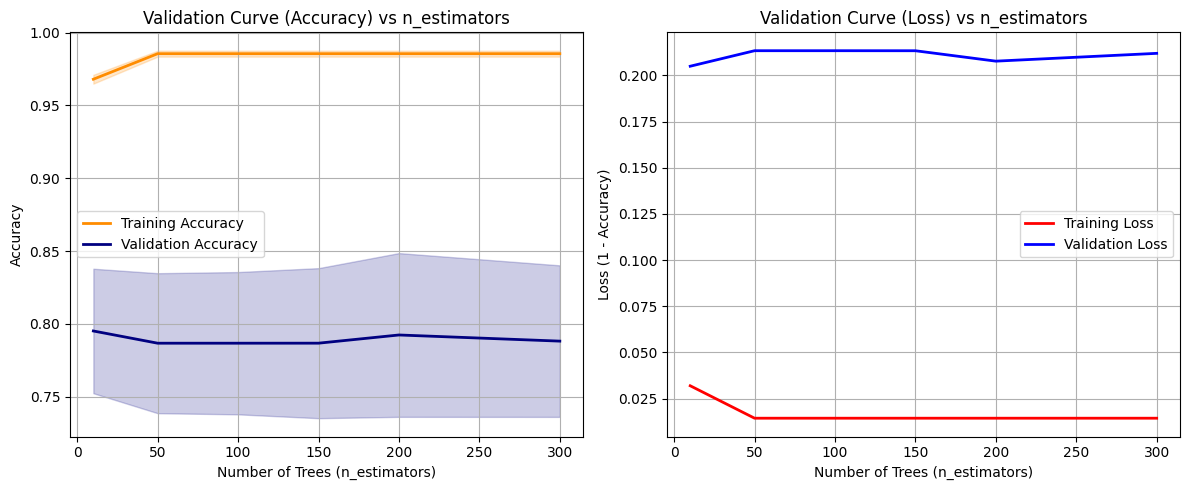

In [8]:
# 4. Validation Curves (Accuracy/Loss vs n_estimators)
param_range = [10, 50, 100, 150, 200, 300]
train_scores, test_scores = validation_curve(
    RandomForestClassifier(random_state=42),
    X_train_proc, y_train,
    param_name="n_estimators",
    param_range=param_range,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

train_loss_mean = 1.0 - train_scores_mean
test_loss_mean = 1.0 - test_scores_mean

plt.figure(figsize=(12, 5))

# Accuracy Graph
plt.subplot(1, 2, 1)
plt.plot(param_range, train_scores_mean, label="Training Accuracy", color="darkorange", lw=2)
plt.fill_between(param_range, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.2, color="darkorange")
plt.plot(param_range, test_scores_mean, label="Validation Accuracy", color="navy", lw=2)
plt.fill_between(param_range, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.2, color="navy")
plt.title("Validation Curve (Accuracy) vs n_estimators")
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend(loc="best")

# Loss Graph
plt.subplot(1, 2, 2)
plt.plot(param_range, train_loss_mean, label="Training Loss", color="red", lw=2)
plt.plot(param_range, test_loss_mean, label="Validation Loss", color="blue", lw=2)
plt.title("Validation Curve (Loss) vs n_estimators")
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Loss (1 - Accuracy)")
plt.grid(True)
plt.legend(loc="best")

plt.tight_layout()
plt.savefig('validation_curves.png')
plt.show()

        Search Method                                        Best Params  \
0        GridSearchCV  {'max_depth': None, 'min_samples_leaf': 1, 'mi...   
1  RandomizedSearchCV  {'n_estimators': 300, 'min_samples_split': 10,...   

   Test Accuracy  
0       0.810056  
1       0.815642  


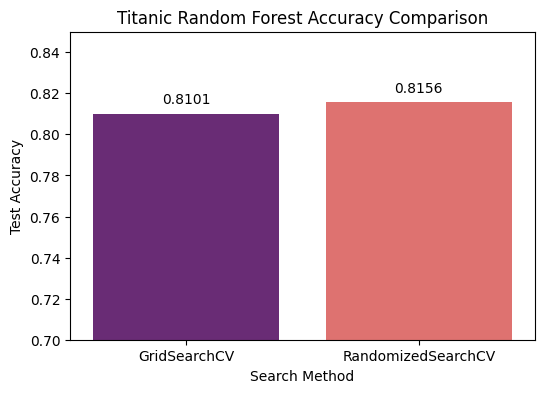

In [9]:
# 5. Evaluation and Comparison
results = {
    'Search Method': ['GridSearchCV', 'RandomizedSearchCV'],
    'Best Params': [str(grid_search.best_params_), str(rand_search.best_params_)],
    'Test Accuracy': [grid_accuracy, rand_accuracy]
}
df_results = pd.DataFrame(results)
print(df_results)

# Plotting Comparison
plt.figure(figsize=(6, 4))
sns.barplot(x='Search Method', y='Test Accuracy', data=df_results, palette='magma')
plt.title('Titanic Random Forest Accuracy Comparison')
plt.ylim(0.7, 0.85)
for index, row in df_results.iterrows():
    plt.text(index, row['Test Accuracy'] + 0.005, f"{row['Test Accuracy']:.4f}", color='black', ha="center")
plt.savefig('titanic_rf_comparison.png')
plt.show()